In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("pair_stability.csv")

# --- 1. Приведение числовых колонок ---
numeric_cols = ["QED", "SA", "MW", "LogP"]

for col in numeric_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .astype(float)
    )

C:\Users\yarat\AppData\Local\Temp\ipykernel_10496\1759904174.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_to_plot, labels=labels, patch_artist=True,
C:\Users\yarat\AppData\Local\Temp\ipykernel_10496\1759904174.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_to_plot, labels=labels, patch_artist=True,
C:\Users\yarat\AppData\Local\Temp\ipykernel_10496\1759904174.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_to_plot, labels=labels, patch_artist=True,
C:\Users\yarat\AppData\Local\Temp\ipykernel_10496\1759904174.py:26: Matplotl

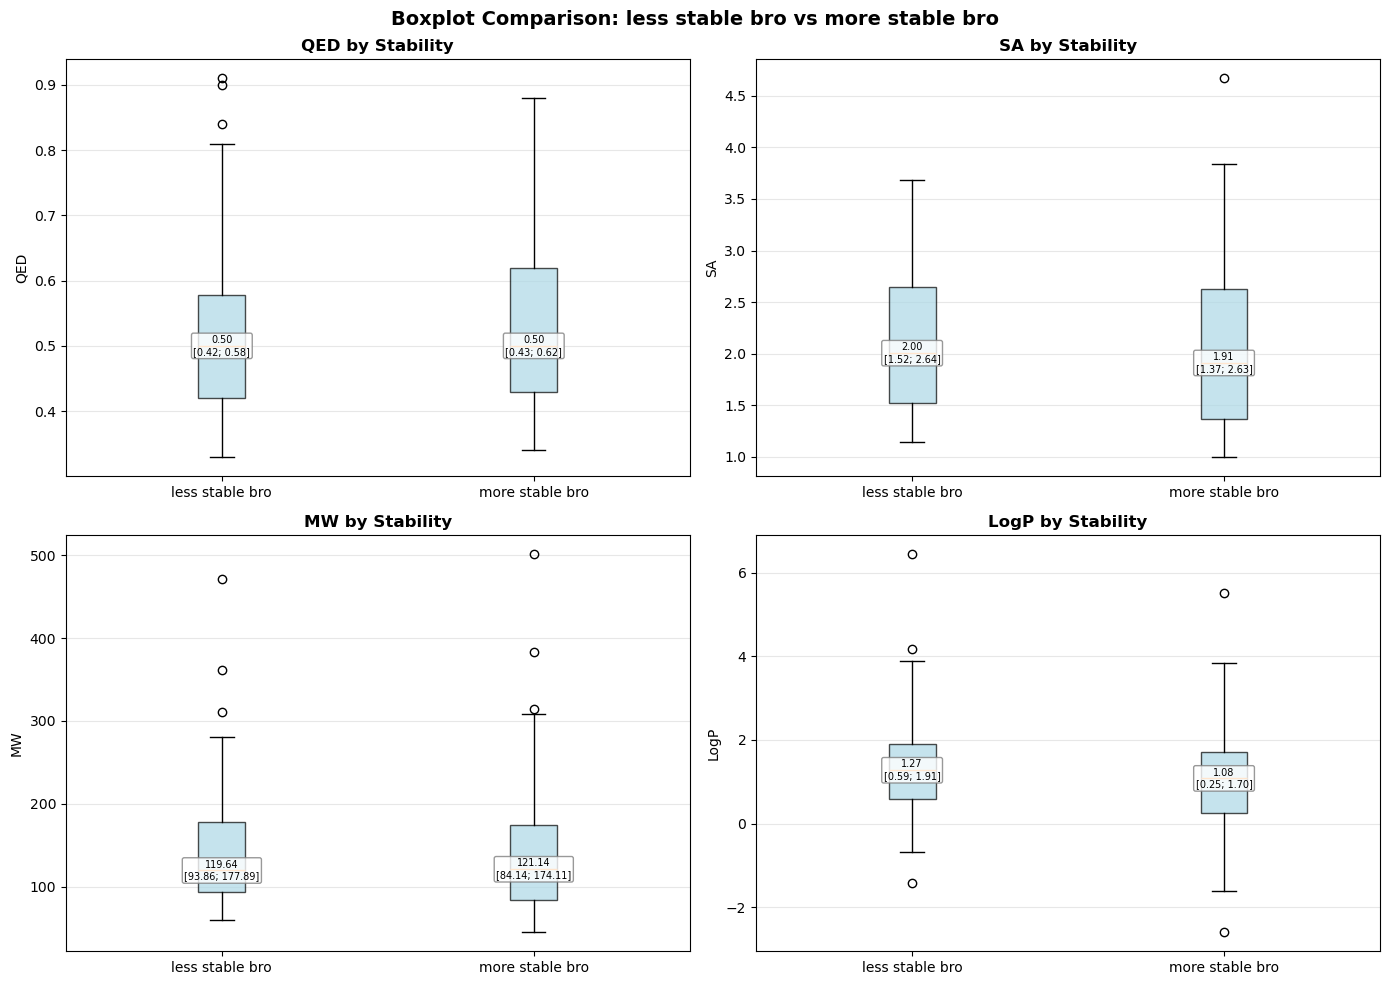

In [17]:
# ============================================
# 1. СРАВНЕНИЕ МЕЖДУ less stable bro И more stable bro
# ============================================

categories = ['less stable bro', 'more stable bro']
df_stability = df[df['More stable molecule'].isin(categories)]

# ============================================
# 2. BOXPLOT ДЛЯ СРАВНЕНИЯ СТАБИЛЬНОСТИ
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    # Подготовка данных
    data_to_plot = []
    labels = []
    for cat in categories:
        subset = df_stability[df_stability['More stable molecule'] == cat][col].values
        if len(subset) > 0:
            data_to_plot.append(subset)
            labels.append(cat)
    
    if data_to_plot:
        bp = axes[i].boxplot(data_to_plot, labels=labels, patch_artist=True,
                              boxprops=dict(facecolor='lightblue', alpha=0.7))
        axes[i].set_title(f'{col} by Stability', fontsize=12, fontweight='bold')
        axes[i].set_ylabel(col, fontsize=10)
        axes[i].grid(axis='y', alpha=0.3)
        
        # Добавляем подписи с медианой и квартилями
        for j, cat in enumerate(categories, start=1):
            if len(df_stability[df_stability['More stable molecule'] == cat][col]) > 0:
                subset = df_stability[df_stability['More stable molecule'] == cat][col]
                q1 = subset.quantile(0.25)
                median = subset.quantile(0.5)
                q3 = subset.quantile(0.75)
                
                axes[i].text(
                    j,
                    median,
                    f"{median:.2f}\n[{q1:.2f}; {q3:.2f}]",
                    ha="center",
                    va="center",
                    fontsize=7,
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.8)
                )

plt.suptitle('Boxplot Comparison: less stable bro vs more stable bro', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


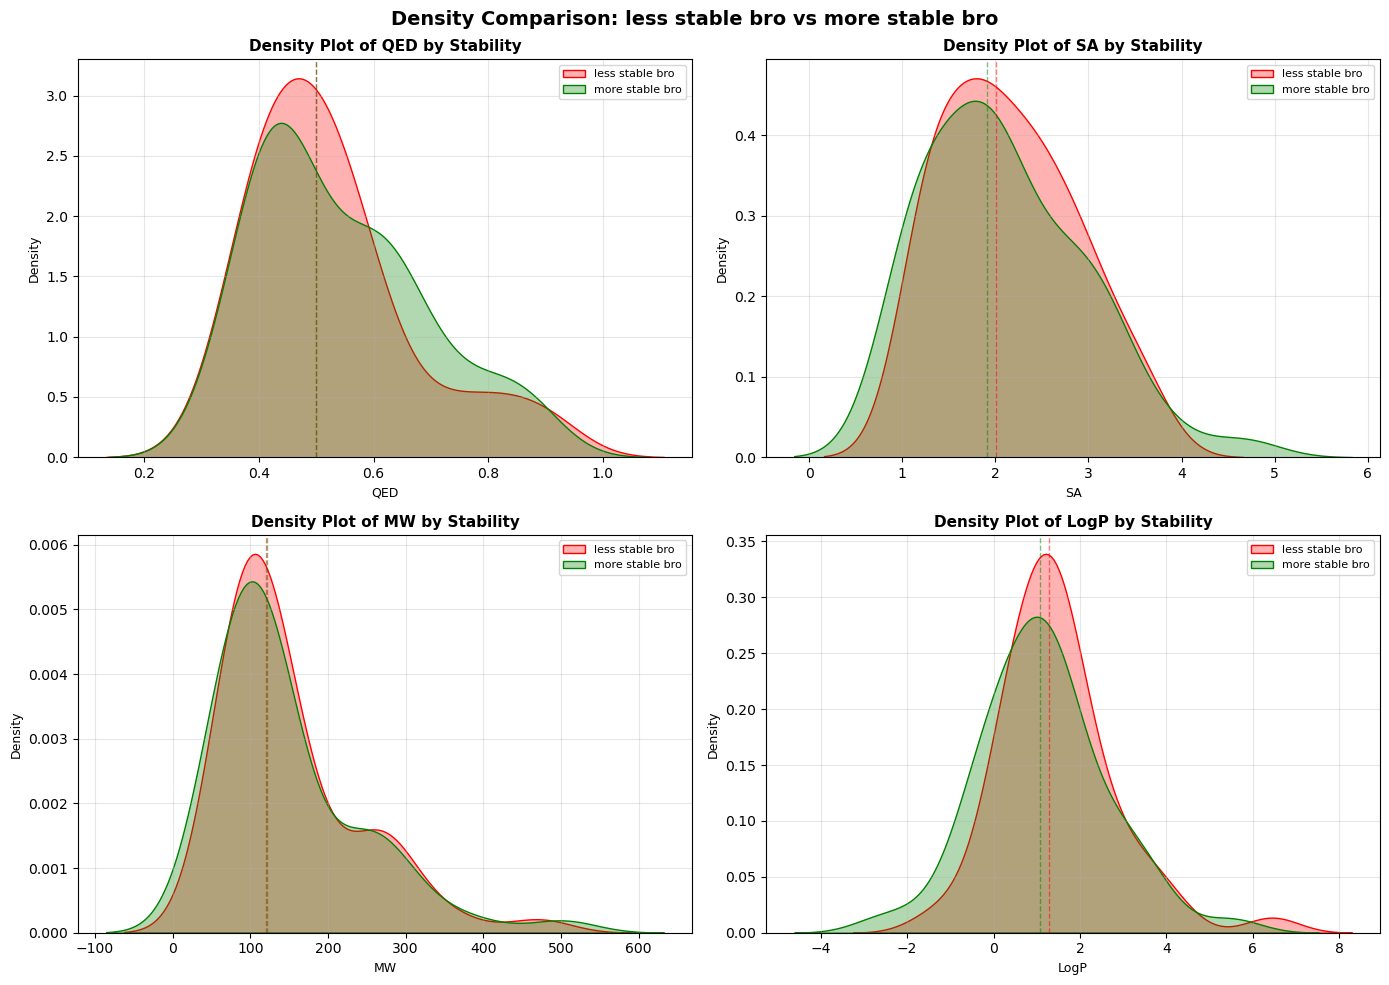

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

colors = {'less stable bro': 'red', 'more stable bro': 'green'}

for i, col in enumerate(numeric_cols):
    for cat in categories:
        subset = df_stability[df_stability['More stable molecule'] == cat][col].dropna()
        if len(subset) > 0:
            sns.kdeplot(subset, label=cat, fill=True, alpha=0.3,
                       color=colors.get(cat, 'blue'), ax=axes[i])
            # Добавляем вертикальные линии для медиан
            median_val = subset.median()
            axes[i].axvline(median_val, color=colors.get(cat, 'blue'), 
                          linestyle='--', alpha=0.5, linewidth=1)
    
    axes[i].set_title(f'Density Plot of {col} by Stability', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=9)
    axes[i].set_ylabel('Density', fontsize=9)
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Density Comparison: less stable bro vs more stable bro', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()